In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import requests
import pyvips

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import os

In [37]:
!pip install "pyvips[binary]"

DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 5.7 MB/s eta 0:00:0000:0100:01
  DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621

[notice] A new release of pip is available: 23.0.1 -> 24.0
[notice] To update, run: /usr/local/opt/python/bin/python3.7 -m pip in

In [6]:
def read_logos_to_dict(filename):
    with open(filename, 'r') as f:
        content = f.read().strip()

    
    # Parse the JSON string
    full_data = json.loads(content)
    
    # Extract the mapping dictionary
    logo_map = full_data.get('qbLogoMap', {})
    clean_logo_dict = {name.split('. ', 1)[-1]: url for name, url in logo_map.items()}
    
    return clean_logo_dict

# Usage
logos_dict = read_logos_to_dict('data/logos.json')


In [8]:
# download images
qb_to_img = dict()
for key, val in logos_dict.items():
    response = requests.get(val)
    teamname = val[val.rfind('/')+1:-4]
    print(teamname)
    image = pyvips.Image.svgload_buffer(response.content, dpi=200)
    
    result_path = "data/logos/" + teamname + ".png"

    # 3. Save the resulting image as a PNG
    image.write_to_file(result_path)
    qb_to_img[key] = result_path
    


KC
GB
NE
BUF
NE
LV
NYG
SEA
MIA
KC
KC
PIT
BLT
DAL
TB
IND
WAS
IND
WAS
NYG
MIA
BUF
LV
PHI
GB
SF
NYJ
BLT
TEN
IND
ARZ
KC
CAR
NYJ
NO
LAC
HST
CIN
ATL
CAR
MIN
GB
NYG
ATL
WAS
DAL
HST
CHI
CLV
SF
CIN
DEN
MIN
SEA
TB
NO
PHI
MIN
LAC
NYJ
BLT
JAX
LA
CLV
PIT
MIA
DET
CIN
ARZ
TEN
LV


In [15]:
# 1. Load the column names
with open('qb-columns.txt', 'r') as f:
    # Filter out the source citation and empty lines
    columns = [line.strip() for line in f if line.strip() and not line.startswith('[source')]

# 2. Load the data
with open('chart_data.json', 'r') as f:
    data = json.load(f)

# 3. Create the DataFrame
df = pd.DataFrame(data, columns=columns)

# 4. Data Cleaning
# Remove ranks from Player Names (e.g., "1. Patrick Mahomes" -> "Patrick Mahomes")
df['Player Name'] = df['Player Name'].str.split('. ', n=1).str[-1]

# List of columns that are percentages
percent_cols = ['Scramble %', 'Sack %', 'Success %', 'Comp %']

for col in df.columns:
    if col in ['Player Name', 'Season', 'Team']:
        continue
    
    # Strip '%' and convert to decimal float (e.g., "50%" -> 0.50)
    if col in percent_cols:
        df[col] = df[col].str.rstrip('%').replace('', np.nan).astype(float) / 100.0
    else:
        # Convert other numeric strings to float/int
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 5. Create a Graph (EPA/Play vs. Success Rate)
# Filter for QBs with > 100 plays for a clearer visualization
df_filtered = df[df['Plays'] > 100].copy()

df_filtered.head()

,Player Name,Season,Team,Plays,Total EPA,EPA/Play,Pass EPA,Rush EPA,Scramble %,Sack %,Success %,ADoT,Comp %,Pass Yards,Time To Throw,Pass TD,INT,YPA,Rush Yards,Rush TD
0,Patrick Mahomes,2025,,254,22.11,0.09,-7.57,29.68,0.2087,0.1299,0.4134,15.03,0.4286,1272,3.86,8,6,7.57,420,3
2,Drake Maye,2025,,270,8.91,0.03,-19.59,28.50,0.2259,0.1741,0.4481,11.87,0.5802,1457,3.51,9,5,8.99,422,2
15,Daniel Jones,2025,,156,-8.60,-0.06,-15.20,6.59,0.1410,0.1410,0.4103,7.94,0.6071,821,2.86,7,0,7.33,147,1
16,Jayden Daniels,2025,,112,-8.63,-0.08,-19.18,10.55,0.3393,0.1518,0.4196,11.63,0.5088,380,3.37,3,1,6.67,246,0
19,Jaxson Dart,2025,,181,-10.11,-0.06,-39.14,29.03,0.2155,0.1934,0.3812,13.47,0.4673,757,3.66,7,2,7.07,299,2


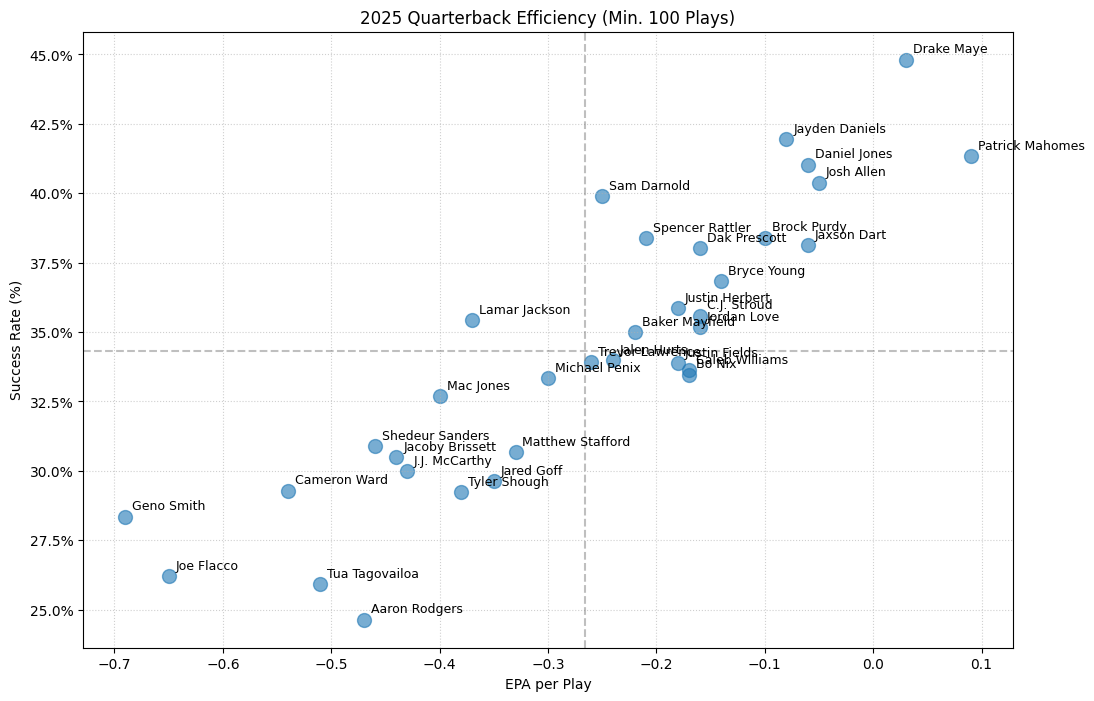

In [3]:
plt.figure(figsize=(12, 8))
plt.scatter(df_filtered['EPA/Play'], df_filtered['Success %'], alpha=0.6, s=100)

# Annotate points with names
for i, row in df_filtered.iterrows():
    plt.annotate(row['Player Name'], (row['EPA/Play'], row['Success %']), 
                 fontsize=9, xytext=(5,5), textcoords='offset points')

# Add average lines to create quadrants
plt.axvline(df_filtered['EPA/Play'].mean(), color='grey', linestyle='--', alpha=0.5)
plt.axhline(df_filtered['Success %'].mean(), color='grey', linestyle='--', alpha=0.5)

plt.xlabel('EPA per Play')
plt.ylabel('Success Rate (%)')
plt.title('2025 Quarterback Efficiency (Min. 100 Plays)')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

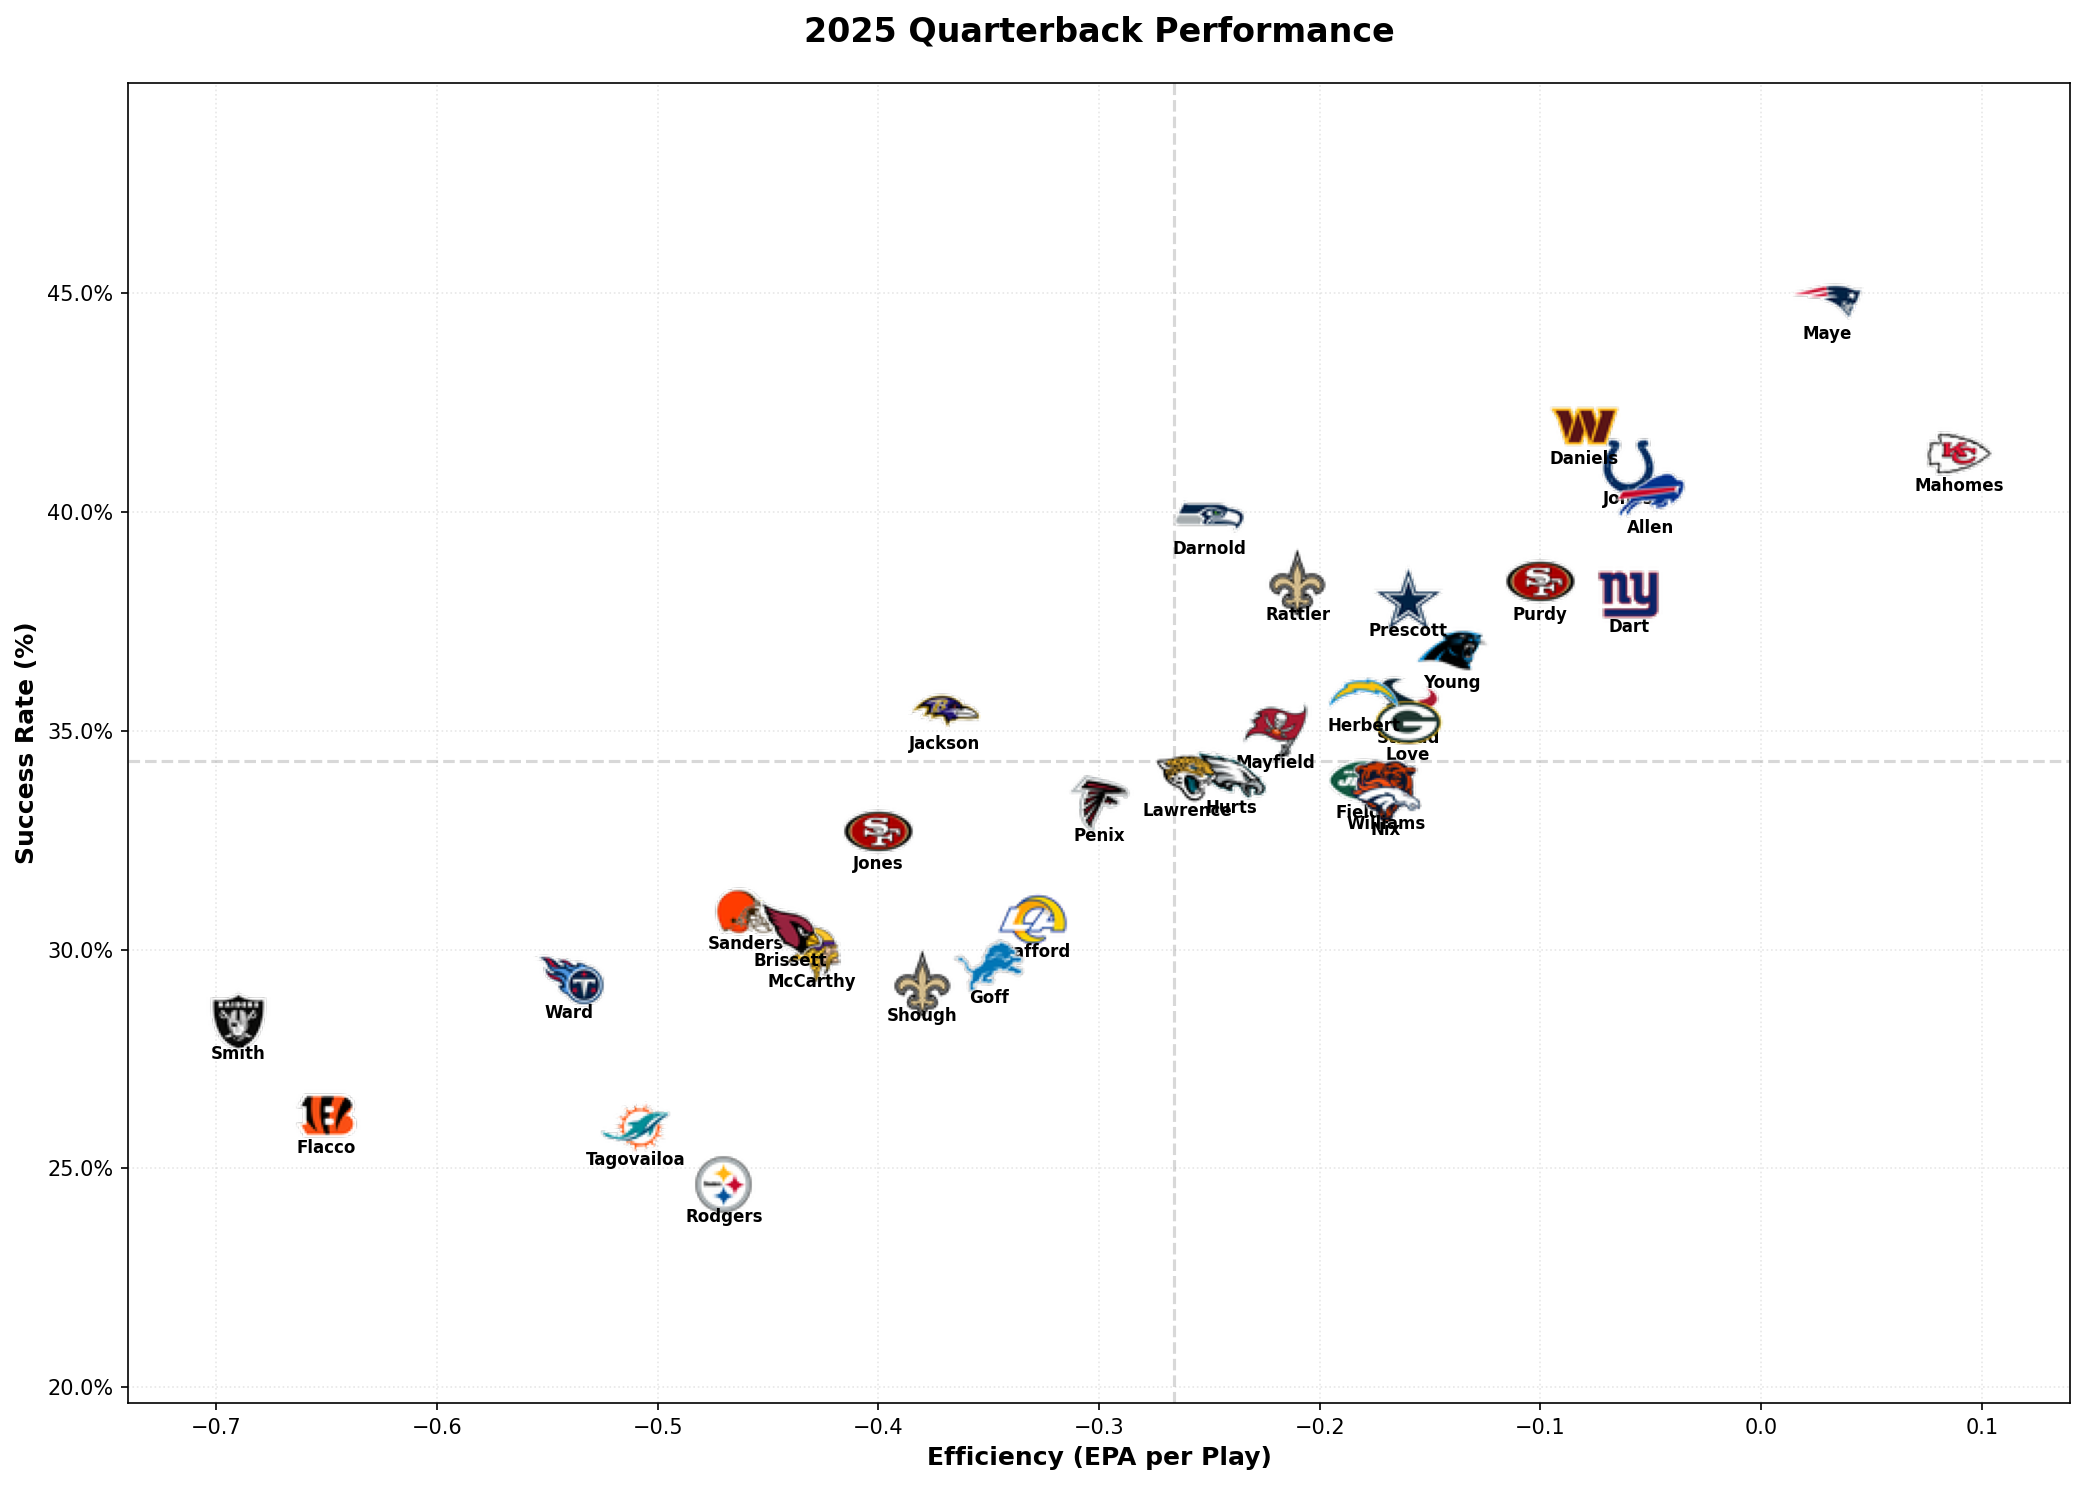

In [67]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.ticker import PercentFormatter
from PIL import Image # Use PIL for high-quality resizing

def getImage(path, zoom_size=40):
    """
    Load image with PIL and resize with LANCZOS interpolation 
    to prevent graininess/aliasing.
    """
    img = Image.open(path)
    # Convert to RGBA to ensure transparency is preserved
    img = img.convert("RGBA")
    
    # Calculate aspect ratio to resize properly
    # instead of a fixed zoom, we define the pixel width/height
    w, h = img.size
    aspect = h / w
    new_w = zoom_size
    new_h = int(new_w * aspect)
    
    # Use LANCZOS for high-quality downsampling
    img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    
    # Return OffsetImage with zoom=1 since we already resized
    return OffsetImage(img, zoom=1.0)

# 1. Increase the Figure DPI for a sharper overall image
fig, ax = plt.subplots(figsize=(14, 10), dpi=150) # 150-300 is ideal

df_plot = df_filtered
mean_epa = df_plot['EPA/Play'].mean()
mean_succ = df_plot['Success %'].mean()

for i, row in df_plot.iterrows():
    # Place the high-quality logo
    # qb_to_img[row['Player Name']] should point to your local PNG path
    logo_path = qb_to_img[row['Player Name']]
    
    # Pass a fixed pixel width (e.g., 40 or 50) instead of a zoom factor
    ab = AnnotationBbox(getImage(logo_path, zoom_size=35), 
                        (row['EPA/Play'], row['Success %']), 
                        frameon=False)
    ax.add_artist(ab)

    # Player name: Black and bigger
    plt.annotate(row['Player Name'].split()[-1], 
                 (row['EPA/Play'], row['Success %']),
                 xytext=(0, -18), # Adjusted for the logo size
                 textcoords='offset points', 
                 fontsize=8, 
                 fontweight='bold',
                 color='black',
                 ha='center')

# Quadrant markers
ax.axvline(mean_epa, color='grey', linestyle='--', alpha=0.3)
ax.axhline(mean_succ, color='grey', linestyle='--', alpha=0.3)

# Formatting
ax.set_xlim(df_plot['EPA/Play'].min() - 0.05, df_plot['EPA/Play'].max() + 0.05)
ax.set_ylim(df_plot['Success %'].min() - 0.05, df_plot['Success %'].max() + 0.05)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.xlabel('Efficiency (EPA per Play)', fontsize=12, fontweight='bold')
plt.ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
plt.title('2025 Quarterback Performance', fontsize=16, fontweight='bold', pad=20)

plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()

# 2. When saving, use a high DPI to maintain the quality
plt.savefig('qb_efficiency_high_res.png', dpi=300, bbox_inches='tight')
plt.show()

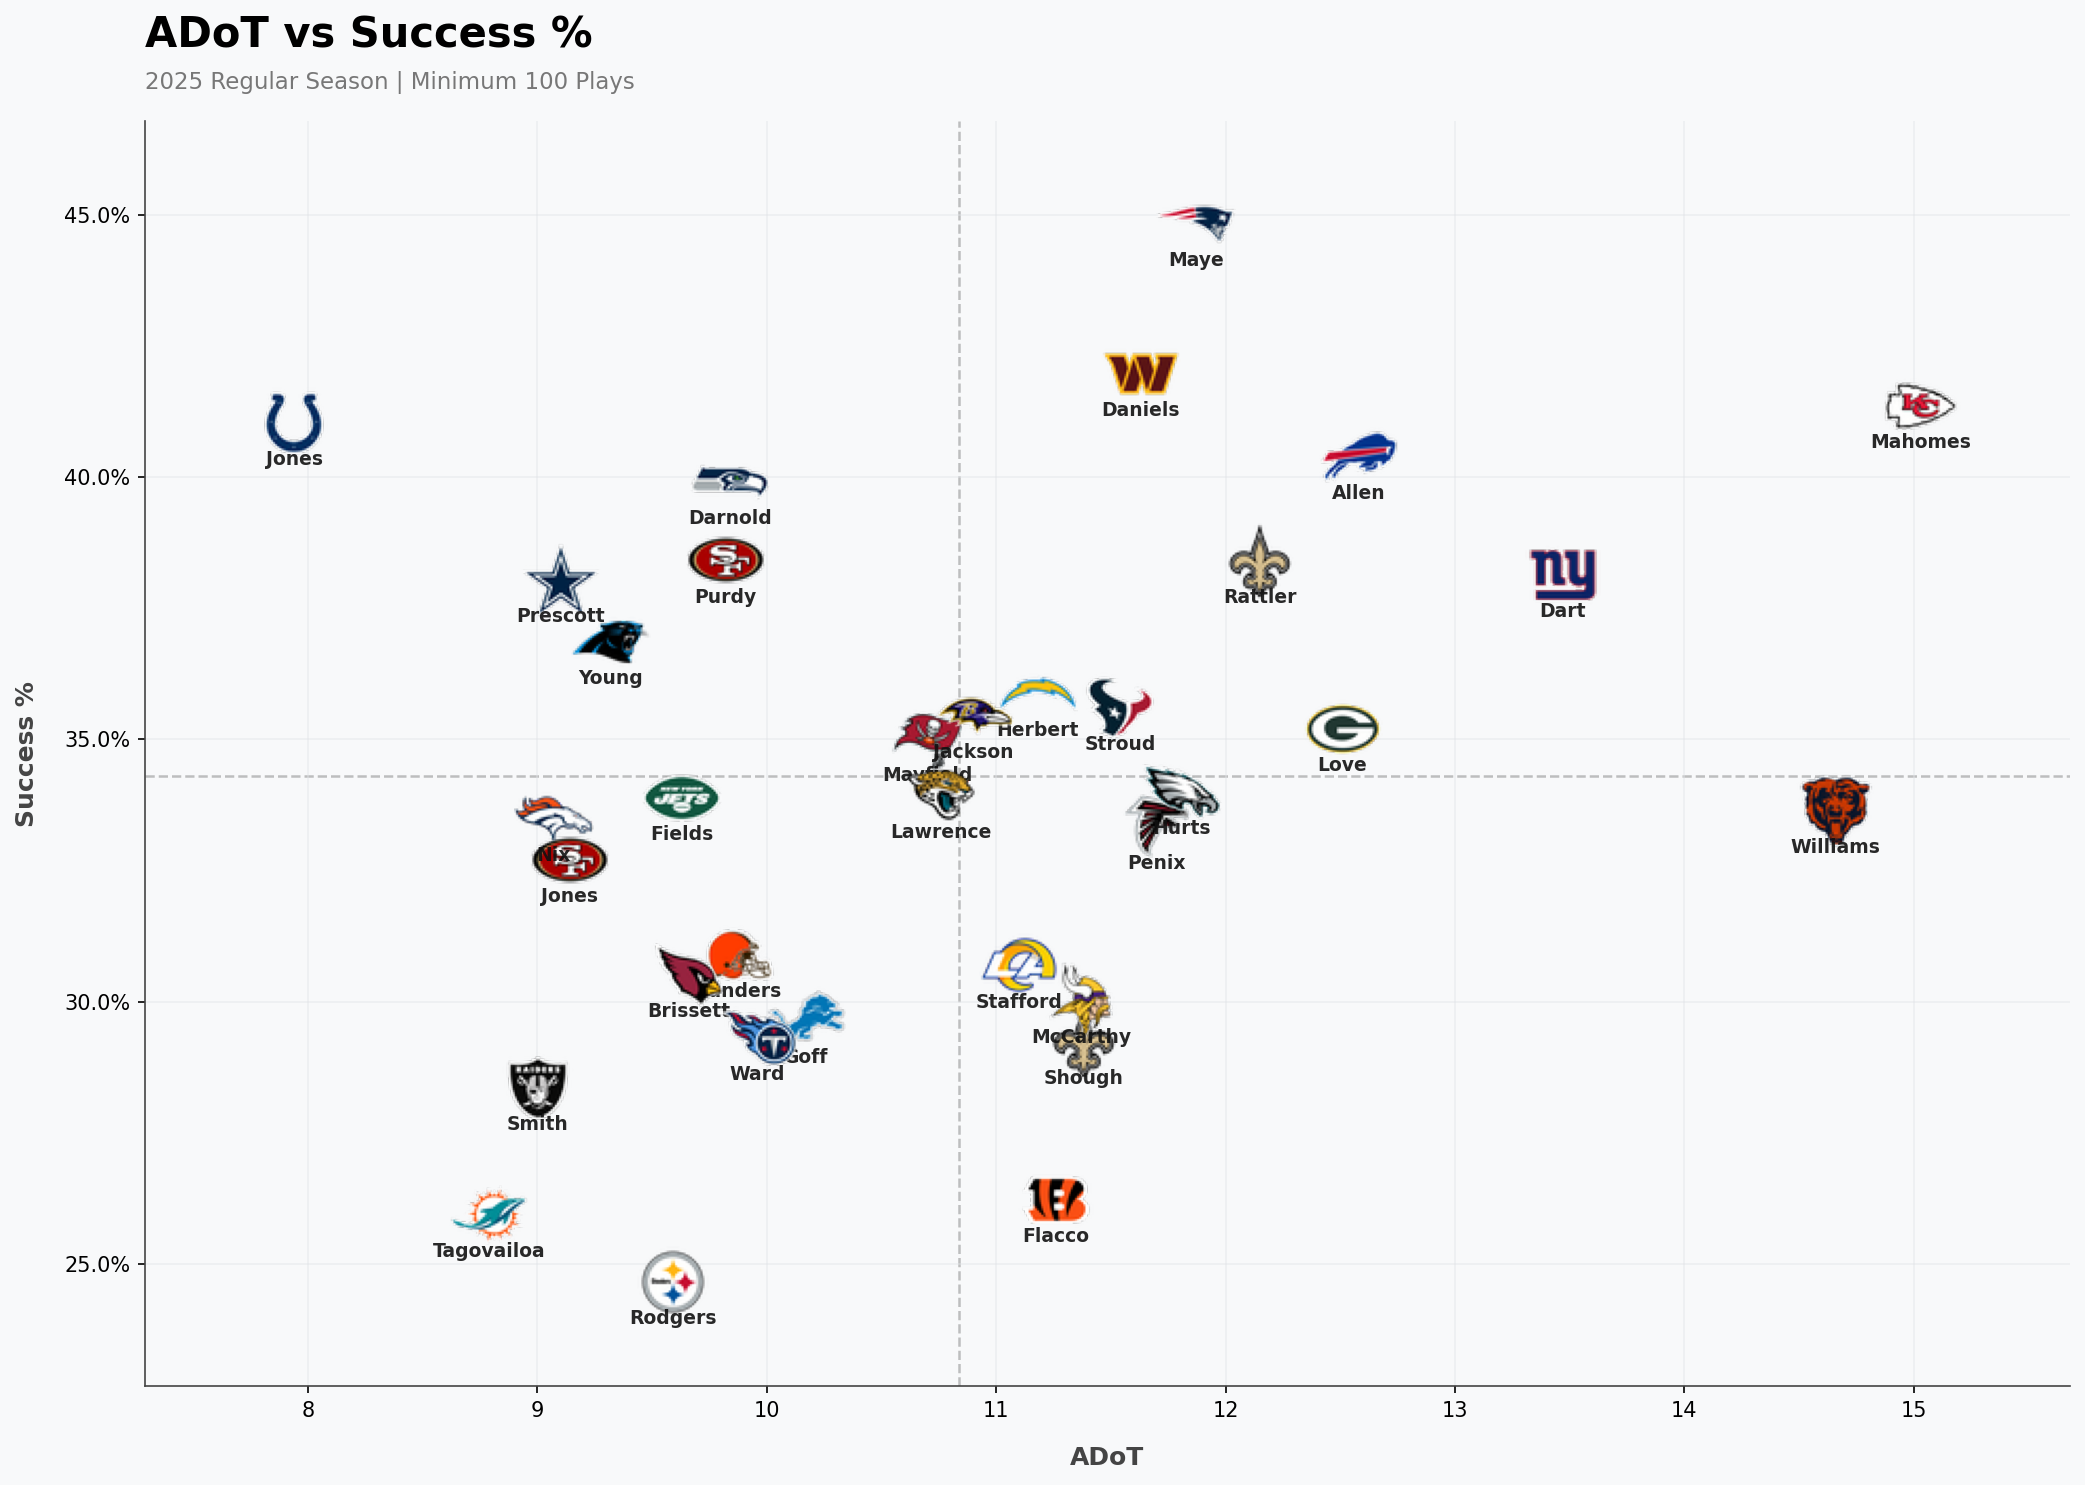

In [1]:
from graphing import create_qb_plot

# --- Example Usage ---
create_qb_plot('data/chart_data.json', 'data/qb-columns.txt', 'ADoT', 'Success %')